# Projet SM604  De la classification des chiffres manuscrits à la détection de cancers du sein
## Mathématiques pour le Machine Learning EFREI Paris 
### par Sabrina El hassani, Aude Labat, Thomas Duriaud, Paul Fontaine, Evan Ladeira



Ce notebook implémente from scratch (NumPy + Python pur) les modèles de classification demandés dans le sujet. L'objectif est de comprendre chaque rouage mathématique sans bibliothèque de machine learning.
## Partie 1 : 

**Structure :**

Section 1.1 Préparation des données MNIST

Section 1.2.1 Modèle linéaire multi-classe

Section 1.2.2 Modèle avec couches cachées H=1 puis H=2

Section 1.2.3 Évaluation, analyse des erreurs et discussion

---
## Section 1.1 - La base de données MNIST

MNIST contient 70 000 images de chiffres manuscrits (0 à 9), chacune au format 28×28 pixels en niveaux de gris.

**Structure de X_raw :**


X_raw : 70 000 lignes × 784 colonnes
1 ligne   = 1 image = 1 vecteur de 784 pixels
1 colonne = 1 pixel pour toutes les images
X_raw[0]  = première image (vecteur de 784 valeurs entre 0 et 255)


Le tableau est en vrac : les images ne sont pas triées par chiffre. Chaque chiffre représente environ 10% du dataset.

**Quatre étapes de préparation :**

**1. Chargement** : importer X et y depuis openml.org

**2. Normalisation** : ramener les pixels de [0, 255] à [0, 1]

**3. Split** : 60 000 images pour entraîner, 10 000 pour évaluer

**4. One-hot** : transformer les étiquettes entières en vecteurs de 10 valeurs

### Imports

In [69]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
import math

np.random.seed(42)

### Chargement

In [70]:
mnist = fetch_openml("mnist_784", version=1, as_frame=False)

X_raw = mnist.data                 # shape (70000, 784), pixels entre 0 et 255
y_raw = mnist.target.astype(int)   # shape (70000,), etiquettes 0 a 9

print(f"X_raw : {X_raw.shape}")
print(f"y_raw : {y_raw.shape}")
print(f"Pixels : min={X_raw.min()}, max={X_raw.max()}")
print(f"Classes : {np.unique(y_raw)}")

X_raw : (70000, 784)
y_raw : (70000,)
Pixels : min=0, max=255
Classes : [0 1 2 3 4 5 6 7 8 9]


### Visualisation

On remet chaque vecteur de 784 valeurs en forme 28×28 pour l'afficher.

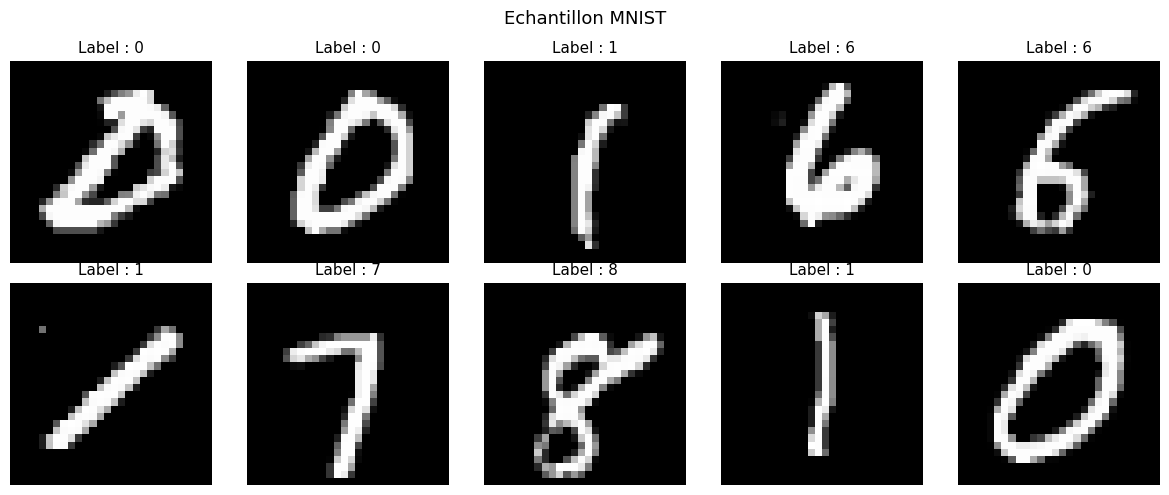

In [71]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):
    idx = np.random.randint(0, len(X_raw))
    img = X_raw[idx].reshape(28, 28)  # vecteur (784,) vers grille (28, 28)
    ax.imshow(img, cmap="gray")       # 0 = noir, 255 = blanc
    ax.set_title(f"Label : {y_raw[idx]}", fontsize=11)
    ax.axis("off")

plt.suptitle("Echantillon MNIST", fontsize=13)
plt.tight_layout()
plt.show()

### Normalisation, split et one-hot

**Pourquoi normaliser ?**

Le score d'un neurone est $o_k = \sum_{j=1}^{784} a_{k,j} x_j + b_k$. C'est une somme de 784 termes. Les poids sont initialisés à environ 0.01. Avec des pixels entre 0 et 255 :
$$784 \times 0.01 \times 127 \approx 1000 \quad \Rightarrow \quad e^{1000} = \infty$$

Avec des pixels dans [0, 1] :
$$784 \times 0.01 \times 0.5 \approx 4 \quad \Rightarrow \quad e^4 = 55 \quad \checkmark$$

**Pourquoi le one-hot ?**

La cross-entropy compare 10 probabilités prédites avec 10 valeurs cibles. L'étiquette doit donc être un vecteur de 10 valeurs, pas un entier. Le sujet définit : $y_i^{(k)} = 1$ si l'image $i$ appartient à la classe $k$, $0$ sinon.

In [72]:
# Normalisation
X = X_raw / 255.0

# Split
X_train = X[:60000]
X_test  = X[60000:]
y_train = y_raw[:60000]
y_test  = y_raw[60000:]

print(f"Train : {X_train.shape}")
print(f"Test  : {X_test.shape}")

print("\nDistribution des classes (train) :")
for d in range(10):
    n = int(np.sum(y_train == d))
    print(f"  Chiffre {d} : {n} ({100*n/len(y_train):.1f}%)")

# One-hot
def one_hot(y, C=10):
    """
    Convertit les etiquettes entieres en matrice one-hot.
    y=3 donne [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]

    y : array (n,) entiers entre 0 et C-1
    Retourne Y : array (n, C)
    """
    n = len(y)
    Y = np.zeros((n, C))
    Y[np.arange(n), y] = 1.0   # pour chaque ligne i, met 1 a la colonne y[i]
    return Y

Y_train = one_hot(y_train)   # (60000, 10)
Y_test  = one_hot(y_test)    # (10000, 10)

print(f"\nEtiquette : {y_train[0]}")
print(f"One-hot   : {Y_train[0]}")

Train : (60000, 784)
Test  : (10000, 784)

Distribution des classes (train) :
  Chiffre 0 : 5923 (9.9%)
  Chiffre 1 : 6742 (11.2%)
  Chiffre 2 : 5958 (9.9%)
  Chiffre 3 : 6131 (10.2%)
  Chiffre 4 : 5842 (9.7%)
  Chiffre 5 : 5421 (9.0%)
  Chiffre 6 : 5918 (9.9%)
  Chiffre 7 : 6265 (10.4%)
  Chiffre 8 : 5851 (9.8%)
  Chiffre 9 : 5949 (9.9%)

Etiquette : 5
One-hot   : [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


---
## Section 1.2.1 - Modèle linéaire multi-classe

### Architecture

Pour chaque image $\vec{x} \in \mathbb{R}^{784}$, on calcule 10 scores, un par classe :

$$o_k = \sum_{j=1}^{784} a_{k,j} x_j + b_k, \quad k \in \{0, ..., 9\}$$

En matriciel : $\vec{o} = A\vec{x} + b$ avec $A \in \mathbb{R}^{10 \times 784}$ et $b \in \mathbb{R}^{10}$.

Le poids $a_{k,j}$ dit "le pixel $j$ compte combien pour reconnaître le chiffre $k$". Les poids sont initialisés aléatoires et petits (×0.01) pour deux raisons : stabilité numérique du softmax, et brisure de symétrie (si tous les poids sont égaux, tous les neurones apprennent la même chose).

Les scores sont convertis en probabilités par le softmax : $P_k = \frac{e^{o_k}}{\sum_j e^{o_j}}$

La prédiction : $\hat{y} = \text{argmax}_k(P_k)$

### Fonction de coût - Cross-entropy

$$L = -\frac{1}{n} \sum_{i=1}^{n} \sum_{k=0}^{9} y_i^{(k)} \cdot \ln(P_k(\vec{x}_i))$$

Grâce au one-hot, un seul terme survit par image : $L = -\frac{1}{n} \sum_i \ln(P_{\text{vraie classe de }i})$

La cross-entropy est plus adaptée que la MSE en classification car elle mesure l’écart entre la distribution de probabilité prédite par le modèle et la distribution réelle des classes, tout en pénalisant fortement les cas où le modèle attribue une très faible probabilité à la vraie classe.

### Calcul du gradient

La démonstration complète du gradient est détaillée dans le rapport.  
Dans le notebook, on rappelle uniquement les formules utilisées pour l’implémentation de la descente de gradient.

On considère le modèle linéaire multi-classe :

$$
o_i = A x_i + b
$$

avec :

$$
A \in \mathbb{R}^{10 \times 784}, \quad x_i \in \mathbb{R}^{784}, \quad b \in \mathbb{R}^{10}
$$

Les scores $o_i$ sont transformés en probabilités avec la fonction softmax :

$$
P_i = \text{softmax}(o_i)
$$

Pour une image $x_i$, le résultat clé obtenu dans la démonstration est :

$$
\boxed{
\frac{\partial L_i}{\partial o_i} = P_i - y_i
}
$$

où $P_i \in \mathbb{R}^{10}$ est le vecteur des probabilités prédites et $y_i \in \mathbb{R}^{10}$ est le vecteur one-hot de la vraie classe.

Pour $n$ images, on range les données sous forme matricielle :

$$
X \in \mathbb{R}^{n \times 784}, \quad Y \in \mathbb{R}^{n \times 10}, \quad P \in \mathbb{R}^{n \times 10}
$$

Le gradient moyen par rapport aux scores est donc :

$$
\boxed{
\frac{\partial L}{\partial O} = \frac{1}{n}(P-Y)
}
$$

On en déduit le gradient par rapport aux poids :

$$
\boxed{
\nabla_A L = \frac{1}{n}(P-Y)^T X
}
$$

avec :

$$
(P-Y)^T X \in \mathbb{R}^{10 \times 784}
$$

ce qui correspond bien à la taille de la matrice $A$.

Le gradient par rapport aux biais est :

$$
\boxed{
\nabla_b L = \frac{1}{n}\sum_{\text{lignes}}(P-Y)
}
$$

avec :

$$
\nabla_b L \in \mathbb{R}^{10}
$$

Les paramètres sont ensuite mis à jour par descente de gradient :

$$
A \leftarrow A - \eta \nabla_A L
$$

$$
b \leftarrow b - \eta \nabla_b L
$$

où $\eta$ désigne le taux d’apprentissage.

### Initialisation des paramètres

In [73]:
def init_params(n_input=784, n_classes=10):
    """
    Cree A (10, 784) et b (10,), les seuls parametres a apprendre.

    A aleatoire petit : evite que o = A.x explose dans le softmax
                        et brise la symetrie entre neurones
    b initialise a zero : A suffit a briser la symetrie
    """
    A = np.random.randn(n_classes, n_input) * 0.01
    b = np.zeros(n_classes)
    return A, b

A, b = init_params()
print(f"A : {A.shape}, valeurs dans [{A.min():.4f}, {A.max():.4f}]")
print(f"b : {b.shape}")

A : (10, 784), valeurs dans [-0.0370, 0.0405]
b : (10,)


### Softmax

$$P_k = \frac{e^{o_k - M}}{\sum_j e^{o_j - M}} \quad \text{avec } M = \max_j(o_j)$$

On soustrait le maximum avant l'exponentielle. C'est mathématiquement identique car $M$ se simplifie en haut et en bas, mais cela évite $e^{\text{grand}} = \infty$ numériquement.

In [74]:
def softmax_python(o):
    """
    Transforme les scores bruts en probabilites.

    o : array (n, 10)
    Retourne P : array (n, 10), chaque ligne somme a 1
    """
    o = np.array(o)
    resultats = []

    for image in o:
        max_score = max(image)
        scores_stables = [s - max_score for s in image]
        exp_scores = [math.exp(s) for s in scores_stables]
        somme = sum(exp_scores)
        probas = [e / somme for e in exp_scores]
        resultats.append(probas)

    return np.array(resultats)

# Test
o_test = np.array([[2.0, 1.0, 0.5, 0.0, 0.0, 0.0, 0.0, 3.4, 0.0, 0.0]])
P_test = softmax_python(o_test)
print(f"Score max a l'indice : {np.argmax(o_test[0])} (chiffre 7)")
print(f"Proba max a l'indice : {np.argmax(P_test[0])} (doit etre 7)")
print(f"Somme des probas     : {P_test[0].sum():.8f}")

Score max a l'indice : 7 (chiffre 7)
Proba max a l'indice : 7 (doit etre 7)
Somme des probas     : 1.00000000


### Cross-entropy

$$L = -\frac{1}{n} \sum_{i=1}^{n} \log(P_{\text{vraie classe de }i})$$

In [75]:
def cross_entropy(P, Y):
    """
    Mesure l'erreur moyenne entre probabilites predites et vraies etiquettes.

    Grace au one-hot, seul le log de la vraie classe compte par image.

    P : (n, 10) probabilites predites
    Y : (n, 10) etiquettes one-hot
    Retourne un scalaire
    """
    n = len(P)
    total = 0
    for i in range(n):
        for k in range(10):
            if Y[i][k] == 1:
                p = max(P[i][k], 1e-12)  # evite ln(0)
                total += math.log(p)
                break
    return -total / n

# Tests
P_parfait = np.array([[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]])
Y_ex      = np.array([[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]])
P_random  = np.full((1, 10), 0.1)
P_faux    = np.array([[0.99, 0.0, 0.01, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]])

print(f"Loss parfaite    : {cross_entropy(P_parfait, Y_ex):.4f}")  # proche de 0
print(f"Loss aleatoire   : {cross_entropy(P_random,  Y_ex):.4f}")  # environ 2.3
print(f"Loss catastrophe : {cross_entropy(P_faux,    Y_ex):.4f}")  # environ 4.6

Loss parfaite    : -0.0000
Loss aleatoire   : 2.3026
Loss catastrophe : 4.6052


### Forward pass

$$O = X \cdot A^T + b$$

$X$ est $(n, 784)$, $A$ est $(10, 784)$. Pour obtenir $O$ de shape $(n, 10)$, on transpose $A$ : $(n, 784) \cdot (784, 10) = (n, 10)$.

In [76]:
def forward(X, A, b):
    """
    Calcule les scores et probabilites pour un batch d'images.

    o = X . A^T + b
    P = softmax(o)

    X : (n, 784)   A : (10, 784)   b : (10,)
    Retourne o : (n, 10) et P : (n, 10)
    """
    o = X @ A.T + b     # (n, 784) . (784, 10) + (10,) = (n, 10)
    P = softmax_python(o)
    return o, P

# Test
o_test, P_test = forward(X_train[:5], A, b)
print(f"o : {o_test.shape}")
print(f"P : {P_test.shape}")
print(f"Somme probas image 0 : {P_test[0].sum():.6f}")

o : (5, 10)
P : (5, 10)
Somme probas image 0 : 1.000000


### Calcul du Gradient

$$\nabla_A L = \frac{1}{n}(P-Y)^T X \qquad \nabla_b L = \frac{1}{n}\sum_{\text{lignes}}(P-Y)$$

In [77]:
def compute_gradient(X, P, Y):
    """
    Calcule le gradient de L par rapport a A et b.

    delta = P - Y : erreur par classe par image, shape (n, 10)
    dA = delta^T . X / n : shape (10, 784), meme shape que A
    db = moyenne de delta sur les images : shape (10,)

    X : (n, 784)   P : (n, 10)   Y : (n, 10)
    Retourne dA : (10, 784) et db : (10,)
    """
    n = len(X)

    delta = []
    for i in range(n):
        ligne = [P[i][k] - Y[i][k] for k in range(10)]
        delta.append(ligne)
    delta = np.array(delta)   # (n, 10)

    dA = (delta.T @ X) / n   # (10, n) . (n, 784) = (10, 784)
    db = []
    for k in range(10):
        db.append(sum(delta[i][k] for i in range(n)) / n)
    db = np.array(db)         # (10,)

    return dA, db

# Verification
X_b = X_train[:3]
_, P_b = forward(X_b, A, b)
Y_b = Y_train[:3]
dA_test, db_test = compute_gradient(X_b, P_b, Y_b)
print(f"dA : {dA_test.shape}")
print(f"db : {db_test.shape}")
print(f"\nGradient dA (5 premieres valeurs du neurone 0) : {dA_test[0][:5]}")
print(f"Gradient db (les 10 biais) : {db_test.round(4)}")

dA : (10, 784)
db : (10,)

Gradient dA (5 premieres valeurs du neurone 0) : [0. 0. 0. 0. 0.]
Gradient db (les 10 biais) : [-0.2281  0.1017  0.1037  0.0991 -0.234  -0.2372  0.11    0.1019  0.0856
  0.0974]


### Taux d'erreur

$$\text{error rate} = \frac{1}{n}\sum_i \mathbf{1}(\hat{y}_i \neq y_i) \quad \text{avec} \quad \hat{y}_i = \text{argmax}_k(P_k)$$

C'est la métrique d'évaluation, distincte de la loss. La loss sert à optimiser (calculer le gradient), le taux d'erreur sert à mesurer la qualité du modèle.

In [78]:
def error_rate(P, y_true):
    """
    Proportion d'images mal classees.

    P      : (n, 10) probabilites predites
    y_true : (n,) etiquettes entieres
    Retourne un scalaire entre 0 et 1
    """
    n = len(y_true)
    erreurs = 0
    for i in range(n):
        max_prob = P[i][0]
        classe_predite = 0
        for k in range(1, 10):
            if P[i][k] > max_prob:
                max_prob = P[i][k]
                classe_predite = k
        if classe_predite != y_true[i]:
            erreurs += 1
    return erreurs / n

# Test avant entrainement
_, P_test_small = forward(X_train[:100], A, b)
err = error_rate(P_test_small, y_train[:100])
print(f"Erreur avant entrainement : {err*100:.1f}%")
print(f"Attendu : environ 90%, les poids sont aleatoires")

Erreur avant entrainement : 89.0%
Attendu : environ 90%, les poids sont aleatoires


### Entraînement : descente de gradient par mini-batches

**Mini-batches vs gradient total**

Le cours (Proposition 5.2) présente le gradient total sur toutes les observations. On utilise des mini-batches de 256 images car :

Avec le gradient total : 1 mise à jour de $A$ par epoch.

Avec des mini-batches de 256 : $60000 \div 256 = 234$ mises à jour de $A$ par epoch. Le modèle apprend 234 fois plus vite par epoch pour le même travail total. Et empêche un temps trop long pour le run

**Choix du learning rate $\eta$**

Le learning rate contrôle la taille du pas : $A \leftarrow A - \eta \nabla_A L$.

On l'observe sur la courbe de loss après entraînement pour :

$\eta = 1.0$ 

$\eta = 0.1$ 

$\eta = 0.01$

**Early stopping**

On s'arrête quand $|L_t - L_{t-1}| < \varepsilon$ (convergence) ou quand l'erreur test remonte 4 fois de suite (overfitting).

In [79]:
def train_linear(X_train, Y_train, y_train, X_test, y_test,
                 lr=0.1, batch_size=256, seuil=1e-4, max_epochs=500):
    """
    Descente de gradient par mini-batches avec early stopping.

    lr         : learning rate eta
    batch_size : images par mini-batch (234 mises a jour par epoch avec 256)
    seuil      : arret si |loss[t] - loss[t-1]| < seuil
    max_epochs : securite contre boucle infinie
    """
    A, b  = init_params()
    n     = len(X_train)
    epoch = 0
    converge = False

    hist_loss  = []
    hist_train = []
    hist_test  = []

    while not converge:

        # Melange : toutes les images vues dans un ordre different a chaque epoch
        indices = np.random.permutation(n)
        X_s = X_train[indices]
        Y_s = Y_train[indices]

        # Mini-batches : 234 mises a jour de A par epoch
        for start in range(0, n, batch_size):
            X_b = X_s[start : start+batch_size]
            Y_b = Y_s[start : start+batch_size]

            _, P_b = forward(X_b, A, b)
            dA, db = compute_gradient(X_b, P_b, Y_b)

            A -= lr * dA   # A <- A - eta . dL/dA
            b -= lr * db   # b <- b - eta . dL/db

        # Evaluation fin d'epoch
        _, P_train = forward(X_train, A, b)
        _, P_test  = forward(X_test,  A, b)

        loss      = cross_entropy(P_train, Y_train)
        err_train = error_rate(P_train, y_train)
        err_test  = error_rate(P_test,  y_test)

        hist_loss.append(loss)
        hist_train.append(err_train)
        hist_test.append(err_test)

        if epoch % 10 == 0:
            print(f"Epoch {epoch:3d} | Loss={loss:.4f} | "
                  f"Train={err_train*100:.2f}% | Test={err_test*100:.2f}%")

        if epoch > 0:
            # Critere 1 : convergence
            diff = abs(hist_loss[-2] - hist_loss[-1])
            if diff < seuil:
                print(f"\nConverge a l'epoch {epoch} (diff={diff:.8f})")
                converge = True
            # Critere 2 : overfitting
            elif epoch > 5:
                if all(hist_test[-i] > hist_test[-i-1] for i in range(1, 5)):
                    print(f"\nEarly stopping epoch {epoch} : overfitting detecte")
                    converge = True

        if epoch >= max_epochs:
            print(f"\nArret : {max_epochs} epochs atteintes")
            converge = True

        epoch += 1

    return A, b, hist_loss, hist_train, hist_test

### Lancement et observation des résultats

**Ce qu'on observe sur les courbes :**

**Courbe de loss** : doit descendre et se stabiliser. Si elle monte, le learning rate est trop grand. Si elle descend trop lentement, il est trop petit.

**Courbe train vs test** :
- Les deux descendent ensemble : le modèle généralise correctement.
- Train descend mais test remonte : overfitting le modèle mémorise le train sans généraliser.
- Les deux restent hauts : underfitting le modèle est trop simple pour les données.

**Résultats attendus** : erreur test entre 8% et 10% pour un modèle linéaire. C'est la baseline qu'on améliorera avec les couches cachées.

Epoch   0 | Loss=0.4694 | Train=12.06% | Test=11.14%
Epoch  10 | Loss=0.3049 | Train=8.48% | Test=8.26%
Epoch  20 | Loss=0.2848 | Train=7.89% | Test=7.88%
Epoch  30 | Loss=0.2755 | Train=7.66% | Test=7.74%

Converge a l'epoch 38 (diff=0.00008116)


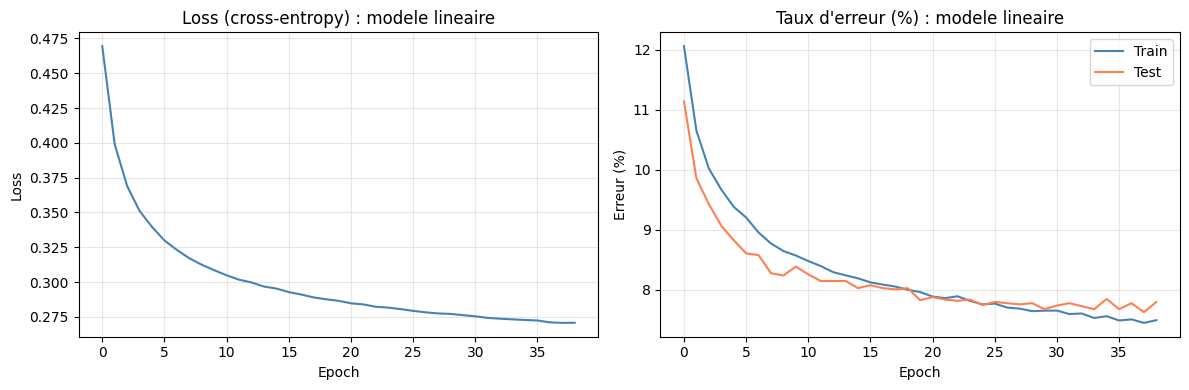


Modele lineaire : resultats finaux
Epochs : 39
Loss   : 0.2708
Train  : 7.50%
Test   : 7.80%
Pas d'overfitting (ecart = 0.30%)


In [80]:
# Entrainement avec lr=0.1
np.random.seed(42)
A_lin, b_lin, losses, err_train_hist, err_test_hist = train_linear(
    X_train, Y_train, y_train,
    X_test,  y_test,
    lr         = 0.1,
    batch_size = 256,
    seuil      = 1e-4,
    max_epochs = 500
)

# Courbes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(losses, color="steelblue")
ax1.set_title("Loss (cross-entropy) : modele lineaire")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.grid(alpha=0.3)

ax2.plot([e*100 for e in err_train_hist], label="Train", color="steelblue")
ax2.plot([e*100 for e in err_test_hist],  label="Test",  color="coral")
ax2.set_title("Taux d'erreur (%) : modele lineaire")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Erreur (%)")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n{'='*50}")
print(f"Modele lineaire : resultats finaux")
print(f"{'='*50}")
print(f"Epochs : {len(losses)}")
print(f"Loss   : {losses[-1]:.4f}")
print(f"Train  : {err_train_hist[-1]*100:.2f}%")
print(f"Test   : {err_test_hist[-1]*100:.2f}%")
diff = abs(err_train_hist[-1] - err_test_hist[-1])
if diff < 0.02:
    print(f"Pas d'overfitting (ecart = {diff*100:.2f}%)")
else:
    print(f"Overfitting detecte (ecart = {diff*100:.2f}%)")

### Visualisation des poids appris

Après entraînement, on remet les poids de chaque neurone en forme 28×28. Les zones rouges (poids positifs forts) sont les pixels qui font monter le score de cette classe.

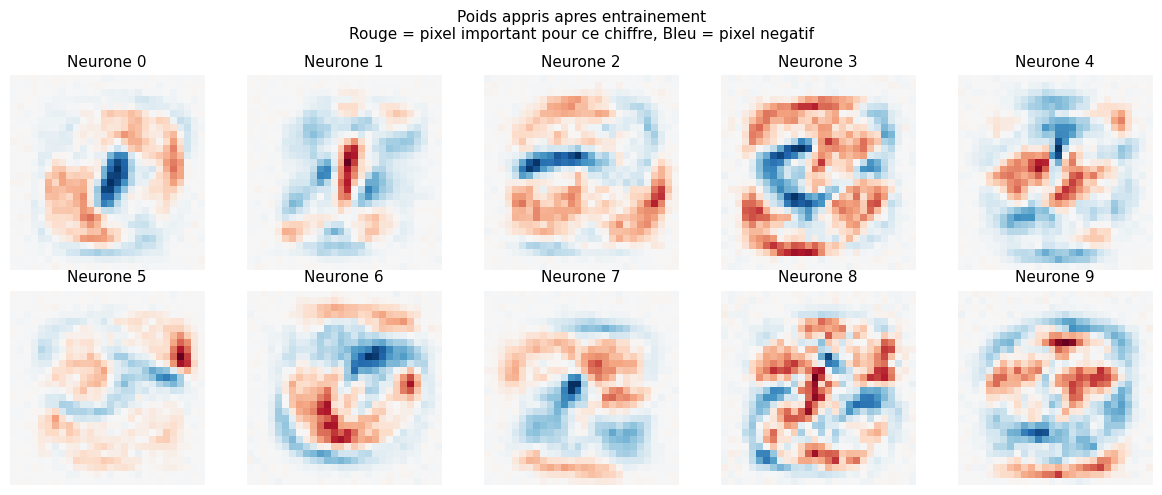

In [81]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for k, ax in enumerate(axes.flat):
    w_img = A_lin[k].reshape(28, 28)
    vmax  = np.max(np.abs(w_img))
    ax.imshow(w_img, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    ax.set_title(f"Neurone {k}", fontsize=11)
    ax.axis("off")

plt.suptitle("Poids appris apres entrainement\nRouge = pixel important pour ce chiffre, Bleu = pixel negatif", fontsize=11)
plt.tight_layout()
plt.show()

### Comparaison des learning rates

| η | Epochs | Erreur train | Erreur test | Verdict |
|---|--------|-------------|-------------|---------|
| 0.1 | 39 | 7.50% | 7.80% | Rapide, meilleure généralisation |
| 0.01 | 184 | 8.03% | 8.00% | 4.7x plus lent, résultat similaire |

**Learning rate retenu : η = 0.1**

Avec η = 0.01, le modèle converge en 184 epochs contre 39 pour η = 0.1 soit 4.7 fois plus lent. Le résultat final est comparable (8.00% vs 7.80% d'erreur test) mais η = 0.1 généralise légèrement mieux. Le modèle linéaire étant convexe, les deux learning rates convergent vers le même minimum global la différence vient uniquement de la vitesse et du bruit des mini-batches.

**η = 0.1 est retenu pour la suite.**

### Limites du modèle linéaire sans couche cachée

**Frontières linéaires uniquement** le modèle utilise 10 hyperplans dans $\mathbb{R}^{784}$, un par classe. Chaque hyperplan répond à la question "ce point de $\mathbb{R}^{784}$ ressemble-t-il à ce chiffre ?". Mais certaines classes comme 3 et 8 ont des points mélangés dans cet espace aucun hyperplan ne peut les séparer parfaitement, d'où les 7.66% d'erreur incompressibles avec ce modèle.

**Aucune mémoire spatiale** les 784 pixels sont traités indépendamment. Le modèle reçoit un vecteur de 784 nombres. Il ne sait pas que ces 784 nombres viennent d'une image 28×28. Pour lui c'est juste une liste de 784 valeurs indépendantes.

**Trop peu de paramètres** 7 850 paramètres ( 10*784+10) pour 60 000 images. Chaque neurone apprend un seul patron moyen par classe alors qu'un chiffre peut s'écrire de dizaines de façons différentes. Le modèle n'a pas assez de capacité pour capturer cette variabilité.

---
## Section 1.2.2 - Modèle avec couches cachées

### Pourquoi ajouter des couches cachées ?

Le modèle linéaire sans couche cachée ne peut tracer que des frontières linéaires (hyperplans) entre les classes. Pour capturer des formes plus complexes, on ajoute des couches intermédiaires avec une activation non-linéaire.

**Architecture H=1 (une couche cachée de p₁ = 128 neurones) :**

$$\vec{x} \rightarrow o^1 = A^1\vec{x} + b^1 \rightarrow z^1 = \text{ReLU}(o^1) \rightarrow o^2 = A^2 z^1 + b^2 \rightarrow P = \text{softmax}(o^2)$$

**Pourquoi ReLU ?** Sans activation non-linéaire, deux couches linéaires reviennent à une seule A2.(A1.x) = (A2.A1).x:
ReLU introduit de la non-linéarité en mettant les valeurs négatives à 0 : $\text{ReLU}(o) = \max(0, o)$. 
Concrètement, certains neurones "s'allument" (valeur positive transmise) et d'autres "s'éteignent" (valeur nulle transmise) selon l'image présentée. Cette sélectivité permet au réseau de créer des frontières de décision courbées impossibles avec un modèle purement linéaire.

**Pourquoi on chosit p₁ = 128 ?** Car c'est une puissance de 2, bon compromis pour la vitesse de calcul. On le justifiera en comparant les taux d'erreur.

**Nombre de paramètres H=1 :**

| Matrice | Shape | Paramètres |
|---------|-------|------------|
| A¹ | (128, 784) | 100 352 |
| b¹ | (128,) | 128 |
| A² | (10, 128) | 1 280 |
| b² | (10,) | 10 |
| **Total** | | **101 770** |

Pour ce modèle on a 101 770 paramètres contre 7 850 pour le modèle linéaire, 13 fois plus de capacité d'expression.

### Fonction d'activation ReLU

ReLU introduit la non-linéarité nécessaire entre les couches. 
Sa dérivée (1 si positif, 0 sinon) est utilisée dans la rétropropagation.

In [82]:
def relu(x):
    """
    Applique ReLU element par element : max(0, x)
    Met les valeurs negatives a 0, garde les positives.

    Sans cette non-linearite, deux couches lineaires
    s'effondrent en une seule : A2.(A1.x) = (A2.A1).x

    x : array de shape quelconque
    Retourne un array de meme shape
    """
    return np.maximum(0, x)        # NumPy : compare chaque valeur a 0 simultanement

def relu_derivative(x):
    """
    Derivee de ReLU element par element.
    Vaut 1 si x > 0, 0 sinon.

    x : array des scores bruts o avant ReLU
    Retourne un array de meme shape avec des 0.0 et des 1.0
    """
    return (x > 0).astype(float)   # True devient 1.0, False devient 0.0

# Test
x_test = np.array([-2.0, -0.5, 0.0, 0.5, 2.0])
print(f"x        : {x_test}")
print(f"relu(x)  : {relu(x_test)}")
print(f"relu'(x) : {relu_derivative(x_test)}")

x        : [-2.  -0.5  0.   0.5  2. ]
relu(x)  : [0.  0.  0.  0.5 2. ]
relu'(x) : [0. 0. 0. 1. 1.]


### Initialisation des paramètres H=1

Deux matrices A¹ et A², deux vecteurs de biais b¹ et b². 
Les shapes découlent directement de l'architecture : (neurones_sortie × neurones_entrée).

In [83]:
def init_params_h1(n_input=784, n_hidden=128, n_classes=10):
    """
    Initialise les parametres pour H=1 couche cachee.

    A1 (128, 784) : poids entree vers couche cachee
    b1 (128,)     : biais couche cachee
    A2 (10, 128)  : poids couche cachee vers sortie
    b2 (10,)      : biais sortie
    """
    A1 = np.random.randn(n_hidden,   n_input)  * 0.01
    b1 = np.zeros(n_hidden)
    A2 = np.random.randn(n_classes,  n_hidden) * 0.01
    b2 = np.zeros(n_classes)
    return A1, b1, A2, b2

A1, b1, A2, b2 = init_params_h1()

print(f"A1 : {A1.shape}   <- {A1.shape[0]} neurones x {A1.shape[1]} pixels")
print(f"b1 : {b1.shape}")
print(f"A2 : {A2.shape}   <- {A2.shape[0]} classes x {A2.shape[1]} neurones")
print(f"b2 : {b2.shape}")
print(f"\nTotal parametres : {A1.size + b1.size + A2.size + b2.size}")

A1 : (128, 784)   <- 128 neurones x 784 pixels
b1 : (128,)
A2 : (10, 128)   <- 10 classes x 128 neurones
b2 : (10,)

Total parametres : 101770


### Forward pass H=1

On calcule les sorties couche par couche, de gauche à droite.
On renvoie o¹ et z¹ car la rétropropagation en aura besoin.

In [84]:
def forward_h1(X, A1, b1, A2, b2):
    """
    Calcul des probabilites pour H=1 couche cachee.

    Couche 1 (cachee) :
        o1 = X . A1^T + b1   scores bruts  shape (n, 128)
        z1 = ReLU(o1)        scores actives shape (n, 128)

    Couche 2 (sortie) :
        o2 = z1 . A2^T + b2  scores bruts  shape (n, 10)
        P  = softmax(o2)     probabilites  shape (n, 10)

    On retourne o1 et z1 en plus car la retropropagation
    a besoin de o1 pour calculer ReLU'(o1)
    et de z1 car c'est l'entree de A2.

    X  : (n, 784)
    A1 : (128, 784)   b1 : (128,)
    A2 : (10, 128)    b2 : (10,)
    Retourne o1, z1, o2, P
    """
    # Couche cachee
    o1 = X  @ A1.T + b1    # (n, 784).(784, 128) + (128,) = (n, 128)
    z1 = relu(o1)           # (n, 128) — valeurs negatives mises a 0

    # Couche de sortie
    o2 = z1 @ A2.T + b2    # (n, 128).(128, 10) + (10,) = (n, 10)
    P  = softmax_python(o2) # (n, 10) — probabilites

    return o1, z1, o2, P

# Test
o1_t, z1_t, o2_t, P_t = forward_h1(X_train[:5], A1, b1, A2, b2)
print(f"o1 : {o1_t.shape}")          # (5, 128)
print(f"z1 : {z1_t.shape}")          # (5, 128)
print(f"o2 : {o2_t.shape}")          # (5, 10)
print(f"P  : {P_t.shape}")           # (5, 10)
print(f"\nSomme probas image 0 : {P_t[0].sum():.6f}")  # 1.0
print(f"Proportion de z1 nuls : {(z1_t == 0).mean()*100:.1f}%")
                                      # proportion de neurones eteints par ReLU

o1 : (5, 128)
z1 : (5, 128)
o2 : (5, 10)
P  : (5, 10)

Somme probas image 0 : 1.000000
Proportion de z1 nuls : 52.3%


### Rétropropagation H=1

La démonstration complète via la règle de la chaîne est détaillée dans le rapport.
On donne ici les formules et leur interprétation.

**Couche de sortie** même résultat que le modèle linéaire :

$$\delta^2 = P - Y \in \mathbb{R}^{n \times 10}$$

$$\nabla_{A^2} L = \frac{1}{n} (\delta^2)^T z^1 \qquad \nabla_{b^2} L = \frac{1}{n}\sum_{\text{lignes}} \delta^2$$



$$\delta^1 = (\delta^2 \cdot A^2) \times \text{ReLU}'(o^1) \in \mathbb{R}^{n \times 128}$$

$$\nabla_{A^1} L = \frac{1}{n} (\delta^1)^T X \qquad \nabla_{b^1} L = \frac{1}{n}\sum_{\text{lignes}} \delta^1$$

**Mise à jour :**

$$A^h \leftarrow A^h - \eta \nabla_{A^h} L \qquad b^h \leftarrow b^h - \eta \nabla_{b^h} L$$

In [85]:
def backward_h1(X, o1, z1, P, Y, A2):
    """
    Calcule les gradients de L par rapport à A1, b1, A2, b2.

    delta2 : erreur en sortie, shape (n, 10)
             c'est une matrice : n images x 10 classes

    delta1 : erreur propagee vers la couche cachee, shape (n, 128)
             delta2 . A2 distribue l'erreur via les poids
             * ReLU'(o1)

    X  : (n, 784)   o1 : (n, 128)   z1 : (n, 128)
    P  : (n, 10)    Y  : (n, 10)    A2 : (10, 128)
    Retourne dA1, db1, dA2, db2
    """
    n = len(X)

    # Couche de sortie
    delta2 = P - Y                          # (n, 10)
    dA2    = (delta2.T @ z1) / n            # (10, n).(n, 128) = (10, 128)
    db2    = delta2.mean(axis=0)            # (10,)

    # Couche cachee
    delta1 = (delta2 @ A2) * relu_derivative(o1)
                                            # (n,10).(10,128) = (n,128)
                                            # * relu_derivative(o1) bloque
                                            # le gradient la où o1 <= 0
    dA1    = (delta1.T @ X) / n            # (128, n).(n, 784) = (128, 784)
    db1    = delta1.mean(axis=0)           # (128,)

    return dA1, db1, dA2, db2

# Test
o1_t, z1_t, o2_t, P_t = forward_h1(X_train[:3], A1, b1, A2, b2)
dA1_t, db1_t, dA2_t, db2_t = backward_h1(
    X_train[:3], o1_t, z1_t, P_t, Y_train[:3], A2
)

print(f"dA1 : {dA1_t.shape}")   # (128, 784)
print(f"db1 : {db1_t.shape}")   # (128,)
print(f"dA2 : {dA2_t.shape}")   # (10, 128)
print(f"db2 : {db2_t.shape}")   # (10,)

dA1 : (128, 784)
db1 : (128,)
dA2 : (10, 128)
db2 : (10,)


### Entraînement H=1

Même structure que le modèle linéaire : mini-batches, early stopping.
À chaque batch on appelle forward_h1 puis backward_h1 pour mettre à jour les 4 paramètres.

In [86]:
def train_h1(X_train, Y_train, y_train, X_test, y_test,
             lr=0.1, batch_size=256, seuil=1e-4, max_epochs=500):
    """
    Entrainement du modele H=1 par descente de gradient mini-batches.

    lr         : learning rate
    batch_size : images par mini-batch
    seuil      : arret si |loss[t] - loss[t-1]| < seuil
    max_epochs : securite contre boucle infinie
    """
    A1, b1, A2, b2 = init_params_h1()
    n     = len(X_train)
    epoch = 0
    converge = False

    hist_loss  = []
    hist_train = []
    hist_test  = []

    while not converge:

        # Melange aleatoire
        indices = np.random.permutation(n)
        X_s = X_train[indices]
        Y_s = Y_train[indices]

        # Mini-batches
        for start in range(0, n, batch_size):
            X_b = X_s[start : start+batch_size]
            Y_b = Y_s[start : start+batch_size]

            # Forward
            o1, z1, o2, P_b = forward_h1(X_b, A1, b1, A2, b2)

            # Backward
            dA1, db1, dA2, db2 = backward_h1(X_b, o1, z1, P_b, Y_b, A2)

            # Mise a jour
            A1 -= lr * dA1
            b1 -= lr * db1
            A2 -= lr * dA2
            b2 -= lr * db2

        # Evaluation fin d'epoch sur tout le dataset X_train et X_test
        _, _, _, P_train = forward_h1(X_train, A1, b1, A2, b2)
        _, _, _, P_test  = forward_h1(X_test,  A1, b1, A2, b2)

        loss      = cross_entropy(P_train, Y_train)
        err_train = error_rate(P_train, y_train)
        err_test  = error_rate(P_test,  y_test)

        hist_loss.append(loss)
        hist_train.append(err_train)
        hist_test.append(err_test)

        if epoch % 10 == 0:
            print(f"Epoch {epoch:3d} | Loss={loss:.4f} | "
                  f"Train={err_train*100:.2f}% | Test={err_test*100:.2f}%")

        if epoch > 0:
            diff = abs(hist_loss[-2] - hist_loss[-1])
            if diff < seuil:
                print(f"\nConverge a l'epoch {epoch} (diff={diff:.8f})")
                converge = True
            elif epoch > 5:
                if all(hist_test[-i] > hist_test[-i-1] for i in range(1, 5)):
                    print(f"\nEarly stopping epoch {epoch} : overfitting detecte")
                    converge = True

        if epoch >= max_epochs:
            print(f"\nArret : {max_epochs} epochs atteintes")
            converge = True

        epoch += 1

    return A1, b1, A2, b2, hist_loss, hist_train, hist_test

### Lancement et résultats H=1

Epoch   0 | Loss=0.4704 | Train=13.37% | Test=12.66%
Epoch  10 | Loss=0.1690 | Train=4.70% | Test=4.95%
Epoch  20 | Loss=0.1037 | Train=2.81% | Test=3.38%
Epoch  30 | Loss=0.0740 | Train=2.02% | Test=2.84%
Epoch  40 | Loss=0.0569 | Train=1.50% | Test=2.50%
Epoch  50 | Loss=0.0453 | Train=1.16% | Test=2.42%

Converge a l'epoch 53 (diff=0.00005422)


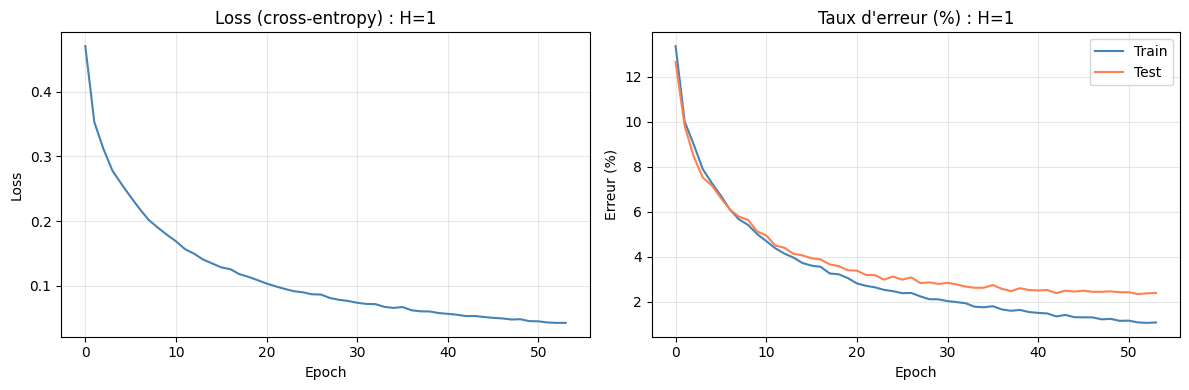


Modele H=1 (128 neurones caches) : resultats
Epochs    : 54
Loss      : 0.0429
Train     : 1.07%
Test      : 2.39%
Accuracy  : 97.61%
Pas d'overfitting (ecart = 1.32%)

Comparaison
Lineaire : Test = 7.80%
H=1      : Test = 2.39%
Gain     : 5.41 points


In [87]:
# Lancement H=1
np.random.seed(42)
A1_fin, b1_fin, A2_fin, b2_fin, losses_h1, err_train_h1, err_test_h1 = train_h1(
    X_train, Y_train, y_train,
    X_test,  y_test,
    lr         = 0.1,
    batch_size = 256,
    seuil      = 1e-4,
    max_epochs = 500
)

# Courbes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(losses_h1, color="steelblue")
ax1.set_title("Loss (cross-entropy) : H=1")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.grid(alpha=0.3)

ax2.plot([e*100 for e in err_train_h1], label="Train", color="steelblue")
ax2.plot([e*100 for e in err_test_h1],  label="Test",  color="coral")
ax2.set_title("Taux d'erreur (%) : H=1")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Erreur (%)")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Resultats
print(f"\n{'='*50}")
print(f"Modele H=1 (128 neurones caches) : resultats")
print(f"{'='*50}")
print(f"Epochs    : {len(losses_h1)}")
print(f"Loss      : {losses_h1[-1]:.4f}")
print(f"Train     : {err_train_h1[-1]*100:.2f}%")
print(f"Test      : {err_test_h1[-1]*100:.2f}%")
print(f"Accuracy  : {(1-err_test_h1[-1])*100:.2f}%")

diff = abs(err_train_h1[-1] - err_test_h1[-1])
if diff < 0.02:
    print(f"Pas d'overfitting (ecart = {diff*100:.2f}%)")
else:
    print(f"Overfitting detecte (ecart = {diff*100:.2f}%)")

# Comparaison avec modele lineaire
print(f"\n{'='*50}")
print(f"Comparaison")
print(f"{'='*50}")
print(f"Lineaire : Test = {err_test_hist[-1]*100:.2f}%")
print(f"H=1      : Test = {err_test_h1[-1]*100:.2f}%")
print(f"Gain     : {(err_test_hist[-1] - err_test_h1[-1])*100:.2f} points")

### Modèle H=2  deux couches cachées

On ajoute une deuxième couche cachée de p₂ = 64 neurones.

$$\vec{x} \rightarrow z^1 = \text{ReLU}(A^1\vec{x} + b^1) \rightarrow z^2 = \text{ReLU}(A^2 z^1 + b^2) \rightarrow P = \text{softmax}(A^3 z^2 + b^3)$$

**Pourquoi p₂ = 64 ?** On réduit progressivement la dimension entre les couches (784 → 128 → 64 → 10). Cette compression force le réseau à extraire les caractéristiques les plus importantes à chaque étape

**Nombre de paramètres H=2 :**

| Matrice | Shape | Paramètres |
|---------|-------|------------|
| A¹ | (128, 784) | 100 352 |
| b¹ | (128,) | 128 |
| A² | (64, 128) | 8 192 |
| b² | (64,) | 64 |
| A³ | (10, 64) | 640 |
| b³ | (10,) | 10 |
| **Total** | | **109 386** |

In [88]:
def init_params_h2(n_input=784, n_h1=128, n_h2=64, n_classes=10):
    """
    Initialise les parametres pour H=2 couches cachees.

    A1 (128, 784) : entree vers couche 1
    A2 (64, 128)  : couche 1 vers couche 2
    A3 (10, 64)   : couche 2 vers sortie
    """
    A1 = np.random.randn(n_h1,     n_input) * 0.01
    b1 = np.zeros(n_h1)
    A2 = np.random.randn(n_h2,     n_h1)    * 0.01
    b2 = np.zeros(n_h2)
    A3 = np.random.randn(n_classes, n_h2)   * 0.01
    b3 = np.zeros(n_classes)
    return A1, b1, A2, b2, A3, b3

A1_h2, b1_h2, A2_h2, b2_h2, A3_h2, b3_h2 = init_params_h2()

print(f"A1 : {A1_h2.shape}  <- 128 neurones x 784 pixels")
print(f"A2 : {A2_h2.shape}   <- 64 neurones x 128 neurones")
print(f"A3 : {A3_h2.shape}    <- 10 classes x 64 neurones")
total = A1_h2.size+b1_h2.size+A2_h2.size+b2_h2.size+A3_h2.size+b3_h2.size
print(f"\nTotal parametres : {total}")

A1 : (128, 784)  <- 128 neurones x 784 pixels
A2 : (64, 128)   <- 64 neurones x 128 neurones
A3 : (10, 64)    <- 10 classes x 64 neurones

Total parametres : 109386


### Forward pass H=2

Même logique que H=1 avec une couche supplémentaire.
On stocke o1, z1, o2, z2 pour la rétropropagation.

In [89]:
def forward_h2(X, A1, b1, A2, b2, A3, b3):
    """
    Calcul des probabilites pour H=2 couches cachees.

    Couche 1 :
        o1 = X . A1^T + b1    shape (n, 128)
        z1 = ReLU(o1)         shape (n, 128)

    Couche 2 :
        o2 = z1 . A2^T + b2   shape (n, 64)
        z2 = ReLU(o2)         shape (n, 64)

    Sortie :
        o3 = z2 . A3^T + b3   shape (n, 10)
        P  = softmax(o3)      shape (n, 10)

    X  : (n, 784)
    A1 : (128, 784)   b1 : (128,)
    A2 : (64, 128)    b2 : (64,)
    A3 : (10, 64)     b3 : (10,)
    Retourne o1, z1, o2, z2, o3, P
    """
    # Couche 1
    o1 = X  @ A1.T + b1    # (n, 784).(784, 128) = (n, 128)
    z1 = relu(o1)

    # Couche 2
    o2 = z1 @ A2.T + b2    # (n, 128).(128, 64) = (n, 64)
    z2 = relu(o2)

    # Sortie
    o3 = z2 @ A3.T + b3    # (n, 64).(64, 10) = (n, 10)
    P  = softmax_python(o3)

    return o1, z1, o2, z2, o3, P

# Test
o1_t, z1_t, o2_t, z2_t, o3_t, P_t = forward_h2(
    X_train[:5], A1_h2, b1_h2, A2_h2, b2_h2, A3_h2, b3_h2
)
print(f"o1 : {o1_t.shape}")   # (5, 128)
print(f"z1 : {z1_t.shape}")   # (5, 128)
print(f"o2 : {o2_t.shape}")   # (5, 64)
print(f"z2 : {z2_t.shape}")   # (5, 64)
print(f"o3 : {o3_t.shape}")   # (5, 10)
print(f"P  : {P_t.shape}")    # (5, 10)
print(f"\nSomme probas image 0 : {P_t[0].sum():.6f}")

o1 : (5, 128)
z1 : (5, 128)
o2 : (5, 64)
z2 : (5, 64)
o3 : (5, 10)
P  : (5, 10)

Somme probas image 0 : 1.000000


### Rétropropagation H=2

On remonte de la sortie vers l'entrée, couche par couche.
La démonstration complète via la règle de la chaîne est détaillée dans le rapport.

**Couche de sortie :**
$$\delta^3 = P - Y \qquad \nabla_{A^3} L = \frac{1}{n}(\delta^3)^T z^2 \qquad \nabla_{b^3} L = \frac{1}{n}\sum_{\text{lignes}} \delta^3$$

**Couche 2 :**
$$\delta^2 = (\delta^3 \cdot A^3) \times \text{ReLU}'(o^2) \qquad \nabla_{A^2} L = \frac{1}{n}(\delta^2)^T z^1 \qquad \nabla_{b^2} L = \frac{1}{n}\sum_{\text{lignes}} \delta^2$$

**Couche 1 :**
$$\delta^1 = (\delta^2 \cdot A^2) \times \text{ReLU}'(o^1) \qquad \nabla_{A^1} L = \frac{1}{n}(\delta^1)^T X \qquad \nabla_{b^1} L = \frac{1}{n}\sum_{\text{lignes}} \delta^1$$

In [90]:
def backward_h2(X, o1, z1, o2, z2, P, Y, A2, A3):
    """
    Calcule les gradients pour H=2 couches cachees.

    On part de la sortie (delta3 = P - Y) et on remonte
    couche par couche en appliquant la regle de la chaine.
    A chaque couche : on propage via les poids puis on
    bloque le gradient la où ReLU etait eteint.

    X  : (n, 784)
    o1 : (n, 128)   z1 : (n, 128)
    o2 : (n, 64)    z2 : (n, 64)
    P  : (n, 10)    Y  : (n, 10)
    A2 : (64, 128)  A3 : (10, 64)
    Retourne dA1, db1, dA2, db2, dA3, db3
    """
    n = len(X)

    # Couche de sortie
    delta3 = P - Y                              # (n, 10)
    dA3    = (delta3.T @ z2) / n               # (10, n).(n, 64) = (10, 64)
    db3    = delta3.mean(axis=0)               # (10,)

    # Couche 2
    delta2 = (delta3 @ A3) * relu_derivative(o2)
                                                # (n,10).(10,64) = (n,64)
                                                # * relu_derivative(o2) bloque
                                                # le gradient la ou o2 <= 0
    dA2    = (delta2.T @ z1) / n               # (64, n).(n, 128) = (64, 128)
    db2    = delta2.mean(axis=0)               # (64,)

    # Couche 1
    delta1 = (delta2 @ A2) * relu_derivative(o1)
                                                # (n,64).(64,128) = (n,128)
                                                # * relu_derivative(o1) bloque
                                                # le gradient la ou o1 <= 0
    dA1    = (delta1.T @ X) / n               # (128, n).(n, 784) = (128, 784)
    db1    = delta1.mean(axis=0)              # (128,)

    return dA1, db1, dA2, db2, dA3, db3

# Test
o1_t, z1_t, o2_t, z2_t, o3_t, P_t = forward_h2(
    X_train[:3], A1_h2, b1_h2, A2_h2, b2_h2, A3_h2, b3_h2
)
dA1_t, db1_t, dA2_t, db2_t, dA3_t, db3_t = backward_h2(
    X_train[:3], o1_t, z1_t, o2_t, z2_t, P_t, Y_train[:3], A2_h2, A3_h2
)
print(f"dA1 : {dA1_t.shape}")   # (128, 784)
print(f"dA2 : {dA2_t.shape}")   # (64, 128)
print(f"dA3 : {dA3_t.shape}")   # (10, 64)

dA1 : (128, 784)
dA2 : (64, 128)
dA3 : (10, 64)


### Entraînement H=2

Même structure que H=1, on appelle forward_h2 et backward_h2.

In [91]:
def train_h2(X_train, Y_train, y_train, X_test, y_test,
             lr=0.1, batch_size=256, seuil=1e-4, max_epochs=500):
    """
    Entrainement du modele H=2 par descente de gradient mini-batches.
    """
    A1, b1, A2, b2, A3, b3 = init_params_h2()
    n     = len(X_train)
    epoch = 0
    converge = False

    hist_loss  = []
    hist_train = []
    hist_test  = []

    while not converge:

        # Melange aleatoire
        indices = np.random.permutation(n)
        X_s = X_train[indices]
        Y_s = Y_train[indices]

        # Mini-batches
        for start in range(0, n, batch_size):
            X_b = X_s[start : start+batch_size]
            Y_b = Y_s[start : start+batch_size]

            # Forward
            o1, z1, o2, z2, o3, P_b = forward_h2(
                X_b, A1, b1, A2, b2, A3, b3
            )

            # Backward
            dA1, db1, dA2, db2, dA3, db3 = backward_h2(
                X_b, o1, z1, o2, z2, P_b, Y_b, A2, A3
            )

            # Mise a jour
            A1 -= lr * dA1
            b1 -= lr * db1
            A2 -= lr * dA2
            b2 -= lr * db2
            A3 -= lr * dA3
            b3 -= lr * db3

        # Evaluation fin d'epoch
        _, _, _, _, _, P_train = forward_h2(X_train, A1, b1, A2, b2, A3, b3)
        _, _, _, _, _, P_test  = forward_h2(X_test,  A1, b1, A2, b2, A3, b3)

        loss      = cross_entropy(P_train, Y_train)
        err_train = error_rate(P_train, y_train)
        err_test  = error_rate(P_test,  y_test)

        hist_loss.append(loss)
        hist_train.append(err_train)
        hist_test.append(err_test)

        if epoch % 10 == 0:
            print(f"Epoch {epoch:3d} | Loss={loss:.4f} | "
                  f"Train={err_train*100:.2f}% | Test={err_test*100:.2f}%")

        if epoch > 0:
            diff = abs(hist_loss[-2] - hist_loss[-1])
            if diff < seuil:
                print(f"\nConverge a l'epoch {epoch} (diff={diff:.8f})")
                converge = True
            elif epoch > 5:
                if all(hist_test[-i] > hist_test[-i-1] for i in range(1, 5)):
                    print(f"\nEarly stopping epoch {epoch} : overfitting detecte")
                    converge = True

        if epoch >= max_epochs:
            print(f"\nArret : {max_epochs} epochs atteintes")
            converge = True

        epoch += 1

    return A1, b1, A2, b2, A3, b3, hist_loss, hist_train, hist_test

### Lancement et comparaison finale H=2

Epoch   0 | Loss=2.2971 | Train=88.76% | Test=88.65%
Epoch  10 | Loss=0.1509 | Train=4.35% | Test=4.68%
Epoch  20 | Loss=0.0734 | Train=2.05% | Test=3.21%
Epoch  30 | Loss=0.0405 | Train=1.04% | Test=2.49%
Epoch  40 | Loss=0.0245 | Train=0.51% | Test=2.39%

Converge a l'epoch 49 (diff=0.00007769)


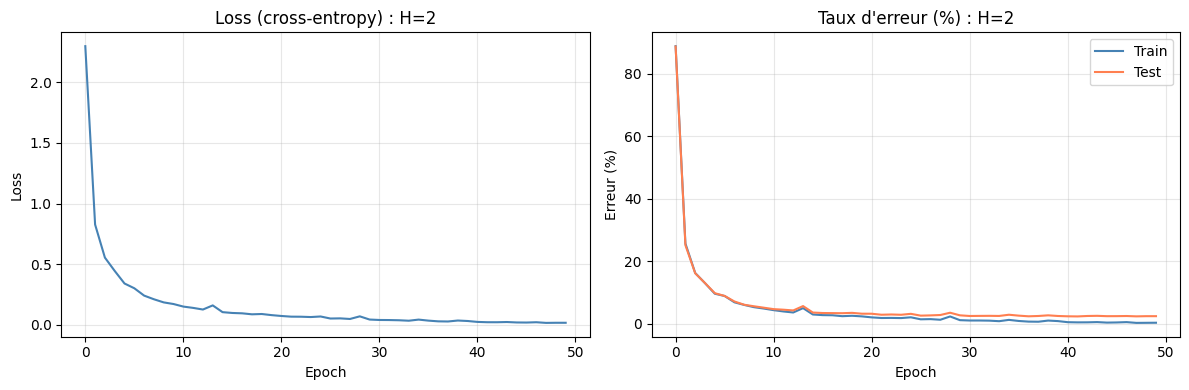


Modele H=2 (128 puis 64 neurones) : resultats
Epochs   : 50
Loss     : 0.0173
Train    : 0.33%
Test     : 2.43%
Accuracy : 97.57%
Overfitting detecte (ecart = 2.10%)


In [92]:
# Lancement H=2
np.random.seed(42)
A1_h2f, b1_h2f, A2_h2f, b2_h2f, A3_h2f, b3_h2f, losses_h2, err_train_h2, err_test_h2 = train_h2(
    X_train, Y_train, y_train,
    X_test,  y_test,
    lr         = 0.1,
    batch_size = 256,
    seuil      = 1e-4,
    max_epochs = 500
)

# Courbes H=2
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(losses_h2, color="steelblue")
ax1.set_title("Loss (cross-entropy) : H=2")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.grid(alpha=0.3)

ax2.plot([e*100 for e in err_train_h2], label="Train", color="steelblue")
ax2.plot([e*100 for e in err_test_h2],  label="Test",  color="coral")
ax2.set_title("Taux d'erreur (%) : H=2")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Erreur (%)")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n{'='*50}")
print(f"Modele H=2 (128 puis 64 neurones) : resultats")
print(f"{'='*50}")
print(f"Epochs   : {len(losses_h2)}")
print(f"Loss     : {losses_h2[-1]:.4f}")
print(f"Train    : {err_train_h2[-1]*100:.2f}%")
print(f"Test     : {err_test_h2[-1]*100:.2f}%")
print(f"Accuracy : {(1-err_test_h2[-1])*100:.2f}%")

diff = abs(err_train_h2[-1] - err_test_h2[-1])
if diff < 0.02:
    print(f"Pas d'overfitting (ecart = {diff*100:.2f}%)")
else:
    print(f"Overfitting detecte (ecart = {diff*100:.2f}%)")

---
## Section 1.2.3 Évaluation, analyse des erreurs et discussion

### Tableau comparatif final

| Modèle | p1 | p2 | Paramètres | Erreur train | Erreur test | Accuracy | Overfitting |
|--------|----|----|------------|-------------|-------------|----------|-------------|
| Linéaire | — | — | 7 850 | 7.50% | 7.80% | 92.20% | Non (0.30%) |
| H=1 | 128 | — | 101 770 | 1.07% | 2.39% | 97.61% | Non (1.32%) |
| H=2 | 128 | 64 | 109 386 | 0.33% | 2.43% | 97.57% | Oui (2.10%) |

**H=1 est le meilleur compromis** meilleure accuracy sans overfitting. H=2 apporte un gain marginal (0.04 point) mais présente de l'overfitting malgré les tentatives de correction :

- Réduire p₂ de 64 à 32 n'a pas suffi 
- Un early stopping sur l'écart train/test résoudrait le problème mais biaiserait l'optimisation en stoppant avant convergence.

**Conclusion : trop de paramètres tuent les paramètres.** Au-delà d'un certain seuil, le réseau sur-apprend.

### Analyse des chiffres mal classés

Nombre d'erreurs sur le test : 239 / 10000
Taux d'erreur : 2.39%


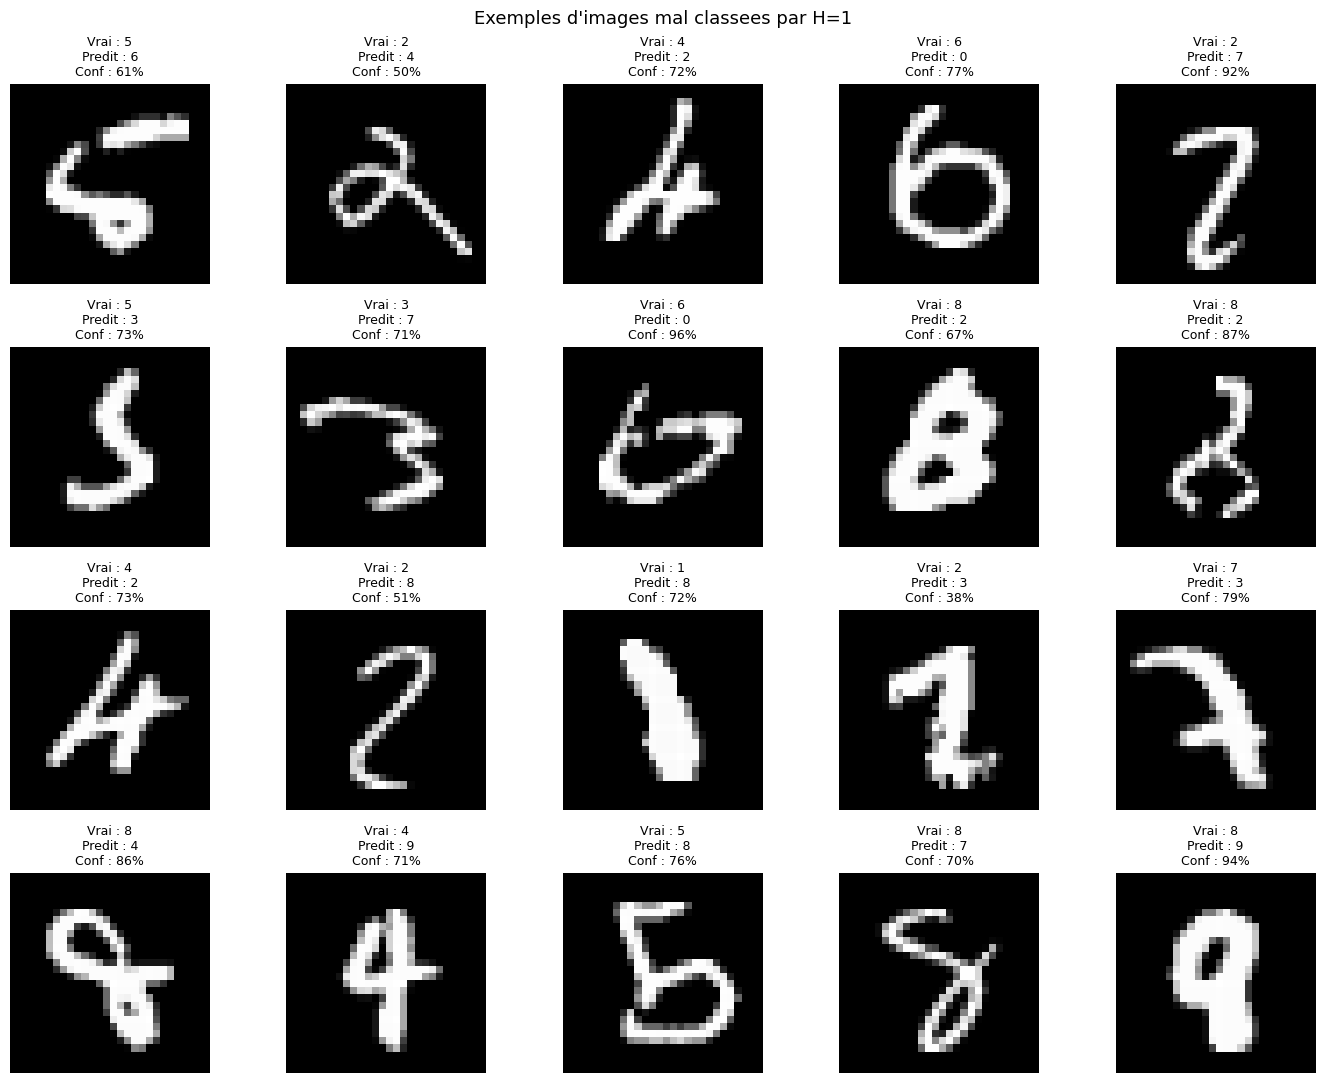

In [93]:
# Récupère les prédictions finales du meilleur modèle (H=1)
_, _, _, P_final = forward_h1(X_test, A1_fin, b1_fin, A2_fin, b2_fin)
y_pred = np.array([np.argmax(P_final[i]) for i in range(len(X_test))])

# Indices des images mal classées
erreurs_idx = np.where(y_pred != y_test)[0]
print(f"Nombre d'erreurs sur le test : {len(erreurs_idx)} / {len(y_test)}")
print(f"Taux d'erreur : {len(erreurs_idx)/len(y_test)*100:.2f}%")

# Affichage des 20 premières erreurs
fig, axes = plt.subplots(4, 5, figsize=(14, 11))
for i, ax in enumerate(axes.flat):
    if i >= len(erreurs_idx):
        ax.axis("off")
        continue
    idx = erreurs_idx[i]
    img = X_test[idx].reshape(28, 28)
    ax.imshow(img, cmap="gray")
    ax.set_title(
        f"Vrai : {y_test[idx]}\nPredit : {y_pred[idx]}\nConf : {P_final[idx][y_pred[idx]]*100:.0f}%",
        fontsize=9
    )
    ax.axis("off")

plt.suptitle("Exemples d'images mal classees par H=1", fontsize=13)
plt.tight_layout()
plt.show()

### Matrice de confusion

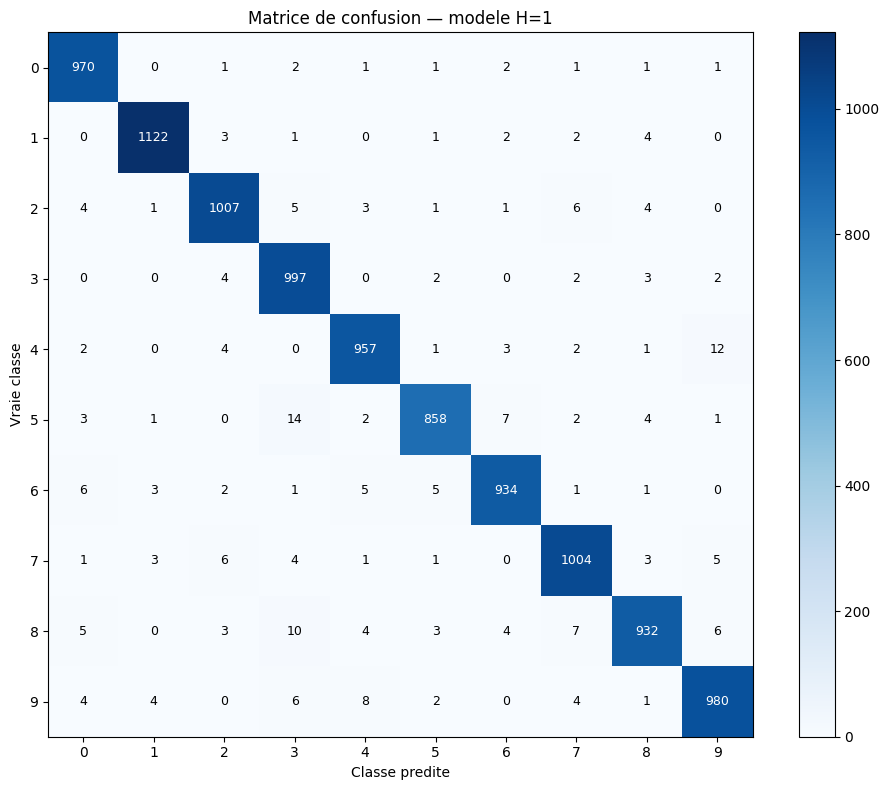


Paires de chiffres les plus souvent confondus :
  5 confondu avec 3 : 14 fois
  4 confondu avec 9 : 12 fois
  8 confondu avec 3 : 10 fois
  9 confondu avec 4 : 8 fois
  8 confondu avec 7 : 7 fois
  5 confondu avec 6 : 7 fois
  9 confondu avec 3 : 6 fois
  8 confondu avec 9 : 6 fois
  7 confondu avec 2 : 6 fois
  6 confondu avec 0 : 6 fois


In [109]:
# Matrice de confusion : ligne = vraie classe, colonne = classe predite
C = 10
confusion = np.zeros((C, C), dtype=int)
for i in range(len(y_test)):
    confusion[y_test[i]][y_pred[i]] += 1

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(confusion, cmap="Blues")
plt.colorbar(im, ax=ax)

ax.set_xticks(range(C))
ax.set_yticks(range(C))
ax.set_xticklabels(range(C))
ax.set_yticklabels(range(C))
ax.set_xlabel("Classe predite")
ax.set_ylabel("Vraie classe")
ax.set_title("Matrice de confusion — modele H=1")

# Affiche les valeurs dans chaque case
for i in range(C):
    for j in range(C):
        couleur = "white" if confusion[i, j] > confusion.max() / 2 else "black"
        ax.text(j, i, str(confusion[i, j]),
                ha="center", va="center", color=couleur, fontsize=9)

plt.tight_layout()
plt.show()

# Paires les plus confondues
print("\nPaires de chiffres les plus souvent confondus :")
confusions = []
for i in range(C):
    for j in range(C):
        if i != j and confusion[i, j] > 0:
            confusions.append((confusion[i, j], i, j))
confusions.sort(reverse=True)
for count, vrai, pred in confusions[:10]:
    print(f"  {vrai} confondu avec {pred} : {count} fois")

### Visualisation 2D réduction par PCA
Représentation en deux dimensions pour illustrer l'analyse.
On projette les images de test dans un espace 2D via PCA pour visualiser
comment les classes se séparent ou non.

Variance expliquee : PC1=9.9%, PC2=7.6%, Total=17.5%


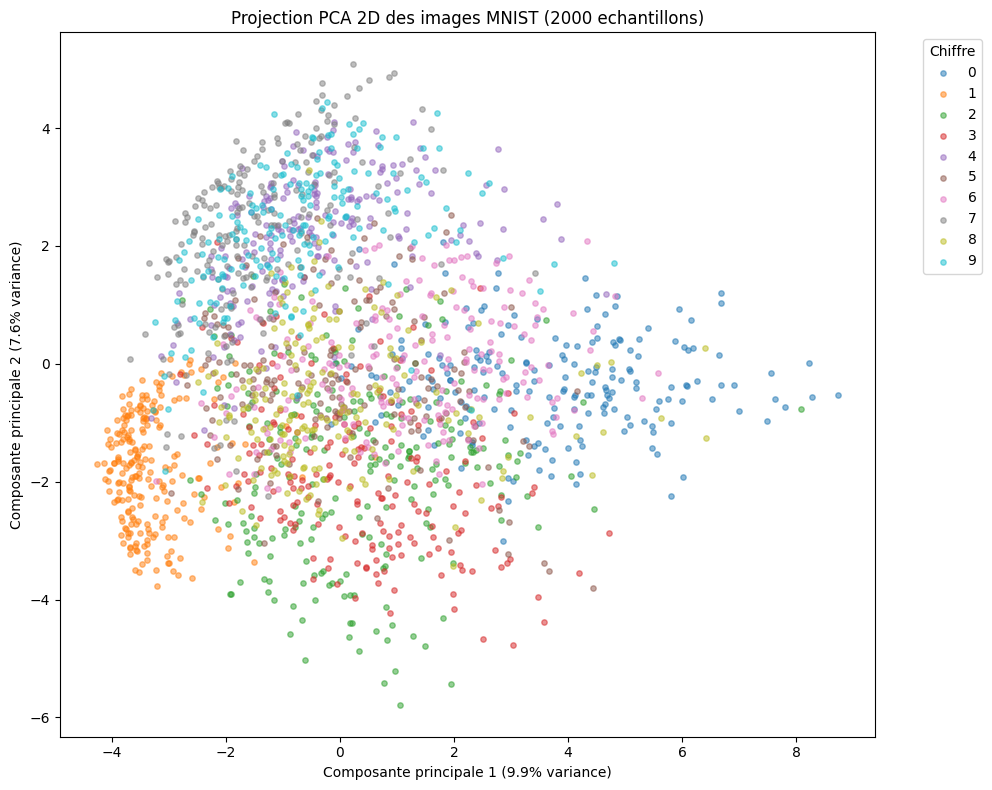

In [110]:
# PCA from scratch : on projette sur les 2 premieres composantes principales
# Centre les donnees
X_test_centered = X_test - X_test.mean(axis=0)

# Matrice de covariance (trop grande sur 784 dims, on prend un sous-ensemble)
n_samples = 2000
idx_sample = np.random.choice(len(X_test), n_samples, replace=False)
X_sample   = X_test_centered[idx_sample]
y_sample   = y_test[idx_sample]

# Decomposition en valeurs singulieres (equivalent PCA)
# On utilise numpy car c'est du calcul matriciel pur
U, S, Vt = np.linalg.svd(X_sample, full_matrices=False)
X_2d = X_sample @ Vt[:2].T   # projection sur les 2 premieres composantes

# Variance expliquee
variance_totale = (S**2).sum()
var_1 = S[0]**2 / variance_totale * 100
var_2 = S[1]**2 / variance_totale * 100
print(f"Variance expliquee : PC1={var_1:.1f}%, PC2={var_2:.1f}%, Total={var_1+var_2:.1f}%")

# Affichage
fig, ax = plt.subplots(figsize=(10, 8))
couleurs = plt.cm.tab10(np.linspace(0, 1, 10))
for k in range(10):
    mask = y_sample == k
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               c=[couleurs[k]], label=str(k), alpha=0.5, s=15)

ax.set_title("Projection PCA 2D des images MNIST (2000 echantillons)")
ax.set_xlabel(f"Composante principale 1 ({var_1:.1f}% variance)")
ax.set_ylabel(f"Composante principale 2 ({var_2:.1f}% variance)")
ax.legend(title="Chiffre", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Analyse des chiffres mal classés

#### Chiffres ambigus

| Confusion | Occurrences | Explication |
|-----------|-------------|-------------|
| 5 → 3 | 14 fois | Même courbure en bas — le trait supérieur du 5 disparaît à l'écriture |
| 4 → 9 | 12 fois | Un 4 avec boucle fermée est visuellement identique à un 9 |
| 8 → 3 | 10 fois | Le 3 ressemble au côté droit d'un 8 mal formé |
| 9 → 4 | 8 fois | Symétrique du cas précédent |
| 8 → 7 | 7 fois | La boucle basse du 8 disparaît parfois à l'écriture |
| 5 → 6 | 7 fois | Même forme de base, différence uniquement sur la boucle du bas |

Ces confusions ne sont pas uniquement des erreurs du modèle — elles reflètent une 
ambiguïté réelle dans l'écriture manuscrite. La paire 5→3 (14 fois) est la plus 
fréquente car ces deux chiffres partagent une courbure inférieure quasi identique.

#### Écritures atypiques

Les images mal classées montrent trois catégories distinctes :

**Écriture ambiguë même pour un humain** 

**Écriture correcte mais atypique**

**Erreur à haute confiance** le 2 prédit comme 7 avec 92% de confiance (ligne 1, 
image 5).

#### Représentation 2D ce que la PCA révèle

La PCA projette les 10 000 images de test en 2D en conservant 18.5% de la variance 
totale (PC1=10%, PC2=7.6%). Malgré cette faible rétention d'information, la 
structure des erreurs est déjà visible.

**Classes bien séparées** les 1 (orange) forment un nuage compact et isolé 
à gauche, les 0 (bleu) s'étirent vers la droite. Ces deux classes ont des formes 
géométriquement opposées (trait vertical vs cercle) leurs erreurs dans la matrice 
sont quasi nulles.

**Classes mélangées** le cœur du nuage central regroupe 3, 5, 6, 8 en 
superposition quasi totale. Ces chiffres partagent des courbes similaires que 
même une projection optimale ne parvient pas à séparer. C'est exactement là 
que se concentrent les confusions majeures : 5→3 (14 fois), 8→3 (10 fois), 5→6 (7 fois).

**La PCA confirme** que le problème ne vient pas uniquement du modèle certains 
chiffres sont intrinsèquement difficiles à distinguer pixel par pixel. Un modèle 
qui exploiterait la structure spatiale (convolution) créerait une meilleure 
séparation dans cet espace.

### Discussion finale

#### Limites du modèle et rôle du nombre de paramètres

| Modèle | Paramètres | Erreur test | Verdict |
|--------|------------|-------------|---------|
| Linéaire | 7 850 | 7.80% | Frontières linéaires insuffisantes |
| H=1 (128) | 101 770 | 2.39% | Meilleur compromis |
| H=2 (128→64) | 109 386 | 2.43% | Overfitting (écart=2.10%) |

Augmenter le nombre de paramètres améliore les performances jusqu'à un seuil. 
H=1 réduit l'erreur de 5.41 points grâce aux 128 neurones cachés qui apprennent 
des représentations intermédiaires avant de décider la classe. H=2 n'apporte 
pas de gain significatif et présente de l'overfitting le réseau mémorise 
les spécificités du train plutôt que d'apprendre des règles généralisables. 
**Trop de paramètres tuent les paramètres.**

#### Pourquoi MNIST reste plus simple que les images naturelles

MNIST bénéficie de conditions idéales absentes dans la vraie vie : chiffres centrés, 
fond noir uniforme, pas de rotation ni de bruit. Ces conditions permettent à un 
modèle traitant les 784 pixels indépendamment d'atteindre 97.6% d'accuracy.

Sur des images naturelles (CIFAR-10), objets et fonds sont complexes la relation 
spatiale entre pixels voisins devient indispensable. C'est précisément ce que les 
convolutions de la partie 2 apportent : des filtres qui analysent des zones locales 
de 3×3 pixels pour détecter contours et textures, là où notre modèle est aveugle.